# **Imitation Learning**
**Autonomous Navigation**  
**Master's Degree in Applied Artificial Intelligence**  
**Tecnológico de Monterrey**  

In [ ]:
# We import Keras and enable its access to our GPU
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras

In [ ]:
# We import all the necessary libraries
import matplotlib.pyplot as plt

from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, Flatten, Concatenate
from keras.layers import Conv2D, MaxPool2D, BatchNormalization
from keras.optimizers import Adam
from keras.utils import to_categorical

from sklearn import datasets
from sklearn import metrics 
from sklearn.metrics import f1_score, accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import numpy as np
import cv2
from PIL import Image
import torch
import pandas as pd

np.random.seed(0)

### **Reading the data**

In [ ]:
# We read the annotations file generated during data collection
annotations_df = pd.read_csv(f'annotations/annotations.csv')
annotations_df = annotations_df.reset_index()

In [ ]:
# We save arrays of the data to be used:
    # X - Images
    # X_cat - Commands
    # y - Angle

X = []
y = []
X_cat = []

In [ ]:
# We iterate through the entire annotations dataset
for index, row in annotations_df.iterrows():

    y.append(float(row['ANGLE']))
    X_cat.append(row['COMMAND'])

    image = Image.open(row['PATH'])
    image = image.convert("RGB")
    imageNP = np.array(image).astype(np.float32)
    imageNP = np.multiply(imageNP, 1.0 / 255.0)
    X.append(imageNP)

### **Preparing the data for the Neural Network**

In [ ]:
# We convert all the arrays into NumPy arrays, and for the categorical ones we do a reshape
X = np.array(X)
y = np.array(y)
X_cat = np.array(X_cat).reshape(-1, 1)

In [ ]:
# We split the data into test and train, stratifying based on the command
X_train, X_test,X_cat_train,X_cat_test, y_train, y_test = train_test_split(X,X_cat, y, test_size=0.3, random_state=42, stratify=X_cat.ravel())
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(29001, 88, 200, 3) (12429, 88, 200, 3) (29001,) (12429,)


In [ ]:
# We create, train, and use a OneHotEncoder so we can use the commands in the model
encoder = OneHotEncoder(sparse_output=False)
X_cat_train = encoder.fit_transform(X_cat_train)  
X_cat_test  = encoder.transform(X_cat_test)  

In [ ]:
# We save the number of classes
n_classes = X_cat_train.shape[1]

### **Defining the neural network architecture**

In [ ]:
# We define the neural network
    # The network is divided into a convolutional network for the images
    # A dense network for the commands
    # The combination of both for a final angle output.
Image_Input = Input(shape=(88, 200, 3))
x = Conv2D(filters=32, kernel_size = (5,5),strides = (2,2) ,input_shape=(200,88,3), activation='relu', padding='valid')(Image_Input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=32, kernel_size = (3,3),strides = (1,1), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=64, kernel_size = (3,3),strides = (2,2), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=64, kernel_size = (3,3),strides = (1,1), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=128, kernel_size = (3,3),strides = (2,2), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=128, kernel_size = (3,3),strides = (1,1), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=256, kernel_size = (3,3),strides = (1,1), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Conv2D(filters=256, kernel_size = (3,3),strides = (1,1), activation='relu', padding='valid')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Flatten()(x)

## Category
cat_input = Input(shape=(n_classes,))
cat_x = Dense(64, activation='relu')(cat_input)
cat_x = Dropout(0.2)(cat_x)
cat_x = Dense(128, activation='relu')(cat_x)
cat_x = Dropout(0.2)(cat_x)

## Union
merged = Concatenate()([x, cat_x])
out = Dense(512, activation='relu')(merged)
out = Dropout(0.3)(out)
out = Dense(1, activation='linear')(out)

model = Model(inputs=[Image_Input, cat_input], outputs=out)
model.compile(Adam(learning_rate=0.0001), loss='mean_squared_error', 
              metrics=['r2_score', 'mean_squared_error'])
print(model.summary())

C:\Users\mario\.conda\envs\keras-torch311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 88, 200, 3)        │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 42, 98, 32)        │           2,432 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 42, 98, 32)        │             128 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 42, 98, 32)        │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 40, 96, 32)        │           9,248 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 40, 96, 32)        │             128 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 40, 96, 32)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 19, 47, 64)        │          18,496 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 19, 47, 64)        │             256 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 19, 47, 64)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 17, 45, 64)        │          36,928 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 17, 45, 64)        │             256 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 17, 45, 64)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 8, 22, 128)        │          73,856 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 8, 22, 128)        │             512 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 5,447,137 (20.78 MB)

 Trainable params: 5,445,217 (20.77 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


### **Defining the Neural Network Hyperparameters and Training it**

In [ ]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # We cut the learning rate in half
    patience=3,          # We wait three epochs before reducing the learning rate
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    [X_train, X_cat_train], y_train,
    validation_data=([X_test, X_cat_test], y_test),
    epochs=40,          
    batch_size=32,       
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/40
907/907 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 1.8100 - mean_squared_error: 1.8100 - r2_score: -3.0753 - val_loss: 0.6159 - val_mean_squared_error: 0.6159 - val_r2_score: -0.4116 - learning_rate: 1.0000e-04
Epoch 2/40
907/907 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - loss: 0.3213 - mean_squared_error: 0.3213 - r2_score: 0.2767 - val_loss: 0.1444 - val_mean_squared_error: 0.1444 - val_r2_score: 0.6689 - learning_rate: 1.0000e-04
Epoch 3/40
907/907 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - loss: 0.1198 - mean_squared_error: 0.1198 - r2_score: 0.7303 - val_loss: 0.1116 - val_mean_squared_error: 0.1116 - val_r2_score: 0.7443 - learning_rate: 1.0000e-04
Epoch 4/40
907/907 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - loss: 0.0918 - mean_squared_error: 0.0918 - r2_score: 0.7933 - val_loss: 0.0999 - val_mean_squared_error: 0.0999 - val_r2_score: 0.7711 - learning_rate: 1.0000e-04
Epoch 5/40
907/907 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - loss: 0.0776 - mean_squared_error: 0.0776 - r2_score: 0.8252 -

### **Visualizing the results**

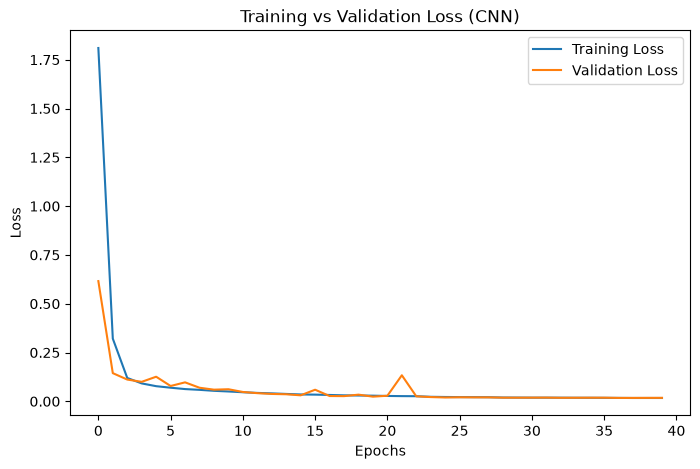

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### **Saving the model**

In [ ]:
# We save the model
model.save('imitation_10_cat.keras')

In [ ]:
# We save the encoder
import pickle

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

### **Usage Example**

In [19]:
with open('encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

In [20]:
loaded_model = keras.saving.load_model("imitation_10_cat.keras")

In [21]:
path = r'test\e84e0cda-b510-4fb8-9d9a-073d7e6d669f_right.png'
command = 'c'
command_encoded = encoder.transform(np.array([[command]]))
image = Image.open(path)
image = image.convert("RGB")
imageNP = np.array(image).astype(np.float32)
imageNP = np.multiply(imageNP, 1.0 / 255.0)
imageNP = np.array([imageNP])

In [22]:
print(imageNP.shape)

(1, 88, 200, 3)


In [23]:
prediction = model.predict([imageNP, command_encoded])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[-0.8098102]]
